## Automatische Kontrastanpassung und Histogrammnormalisierung
In diesem Notebook werden zwei automatisierte bildverbesserungsverfahren vorgestellt: die automatische Kontrastanpassung und die Histogrammnormalisierung. Beide Methoden zielen darauf ab, den Kontrast eines Bildes zu verbessern, indem sie die Verteilung der Graustufenwerte anpassen.

##### Laden der Module

In [2]:
import numpy as np
import scipy
import cv2
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import skimage

##### Hilfsfunktionen laden

In [3]:
from modules.plotting import displayImageAndAllHist 

##### Einlesen des Bildes 

In [4]:
# Bilddateien einladen und anzeigen
img_landscape = cv2.imread(r'images/landscape.png', cv2.IMREAD_GRAYSCALE)
img_unknown = cv2.imread(r'images/unknown.png', cv2.IMREAD_GRAYSCALE)

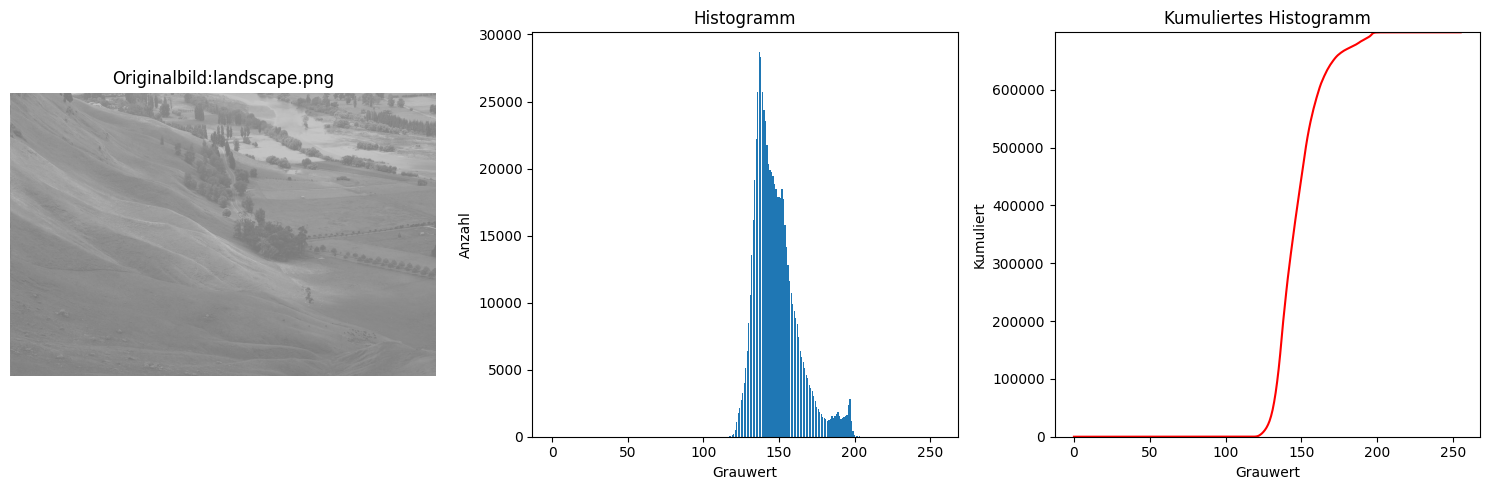

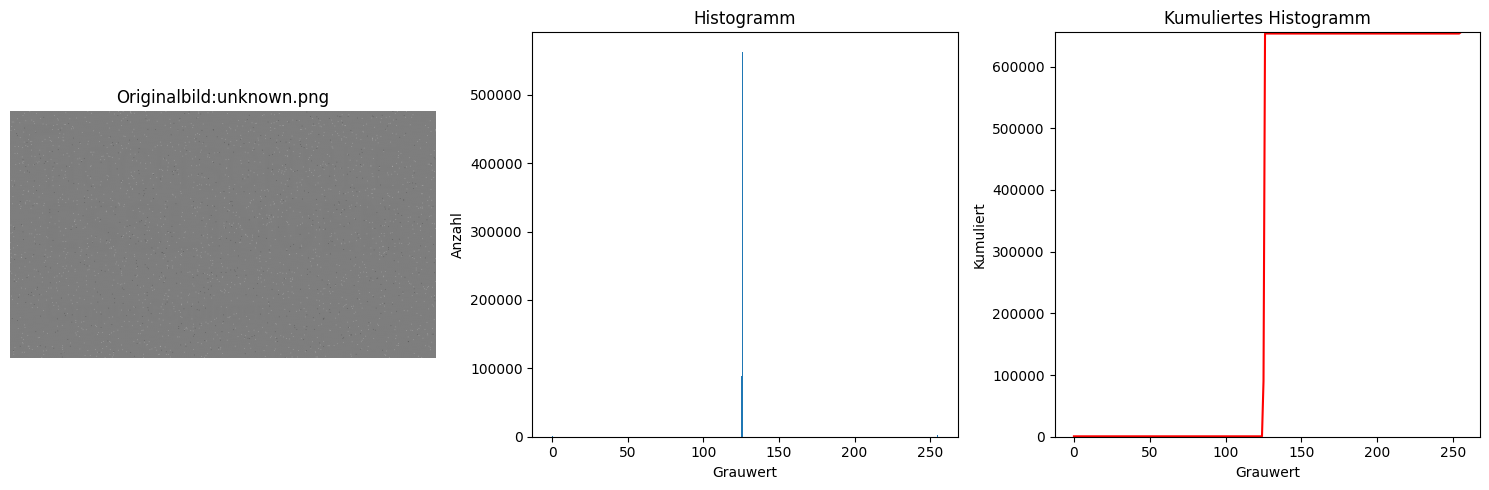

In [5]:
displayImageAndAllHist(img_landscape, 'Originalbild:landscape.png')
displayImageAndAllHist(img_unknown, 'Originalbild:unknown.png')

### Automatische Kontrastanpassung


### Aufgabe:
Schreiben Sie eine Funktion die eine automatische Kontrastanpassung durchführt. Berechnen Sie den minimalen / maximalen Pixelwert und strecken Sie diesen Bereich dann auf den maximalen Wertebereich des Bildes.

In [6]:
def autoContrast(image):
    """Führt eine automatische Kontrastanpassung durch, indem der Wertebereich des Bildes auf [0, 255] gestreckt wird."""

    ####
    ## ENTER YOUR CODE HERE
    ####    


    a_low = np.min(image)
    a_high = np.max(image)
    a_min = 0
    a_max = 255
    
    # Kontrastanpassung durchführen
    adjusted_image = a_min + (image - a_low) * ((a_max - a_min) / (a_high - a_low)) 
    adjusted_image = np.clip(adjusted_image, 0, 255).astype(np.uint8)
    
    return adjusted_image

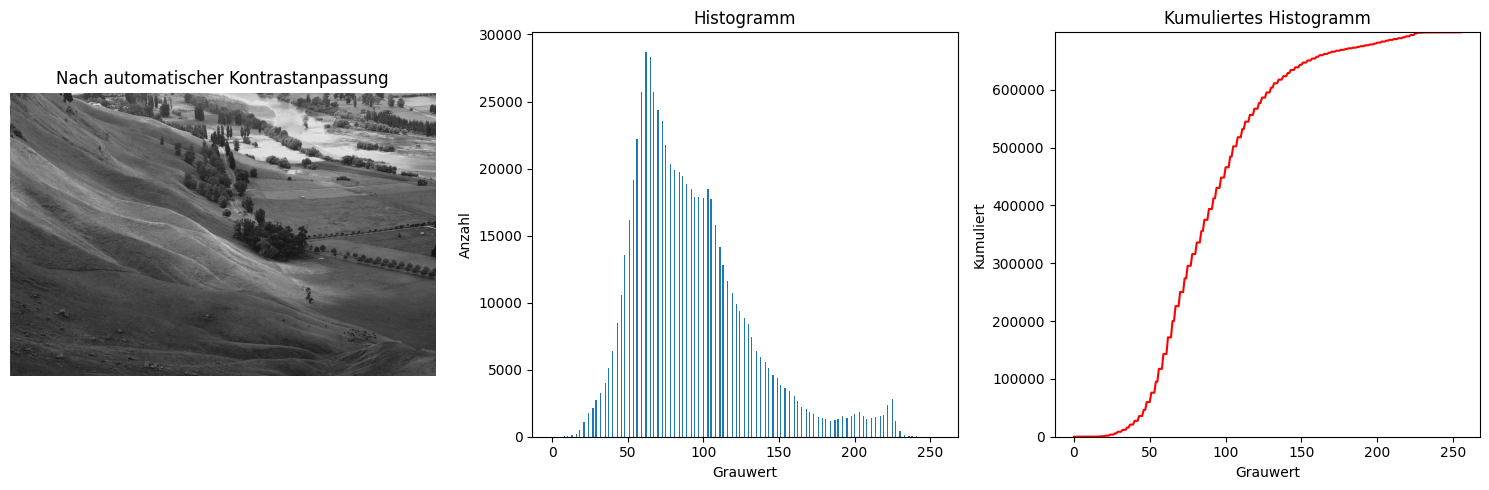

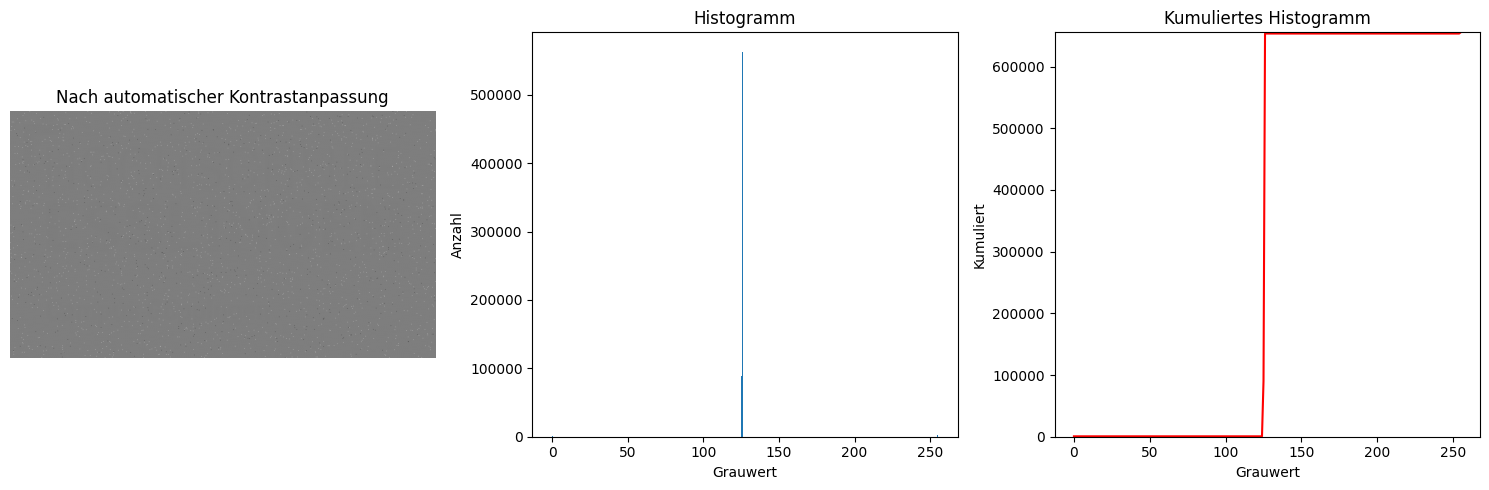

In [7]:
img_landscape_autoC = autoContrast(img_landscape)
displayImageAndAllHist(img_landscape_autoC, 'Nach automatischer Kontrastanpassung')

img_unknown_autoC = autoContrast(img_unknown)
displayImageAndAllHist(img_unknown_autoC, 'Nach automatischer Kontrastanpassung')

### Verbesserte automatische Kontrastanpassung
für das Landschaftsbild war die Kontrastverbesserung schon sehr gut, beim unbekannten Bild konnte jedoch keine Verbesserung beobachtet werden.

### Aufgabe
versuchen Sie die automatische Kontrastanpassung zu verbessern, indem Sie z.B. die unteren und oberen 1% der Pixelwerte ignorieren (Clipping). Berechnen Sie dazu die entsprechenden Schwellenwerte und verwenden Sie diese für die Kontrastanpassung. Testen Sie Ihre Funktion mit beiden Bildern.

In [8]:

def autoContrastSat(image, satPixPercentage):
    """Führt eine automatische Kontrastanpassung durch, indem der Wertebereich des Bildes auf [0, 255] gestreckt wird."""
    
    ####
    ## ENTER YOUR CODE HERE
    ####
    
    
    
    a_low = np.percentile(image, satPixPercentage)
    a_high = np.percentile(image, (100-satPixPercentage))
    a_min = 0
    a_max = 255
    
    # Kontrastanpassung durchführen
    adjusted_image = a_min + (image - a_low) * ((a_max - a_min) / (a_high - a_low)) 
    adjusted_image = np.clip(adjusted_image, 0, 255).astype(np.uint8)
    
    return adjusted_image

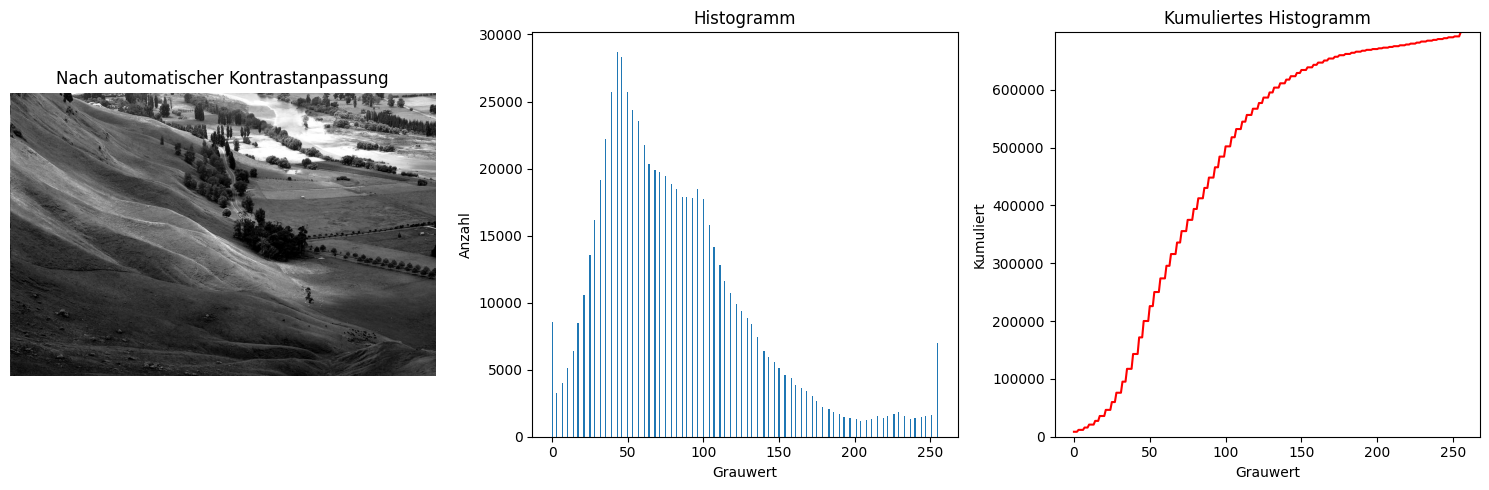

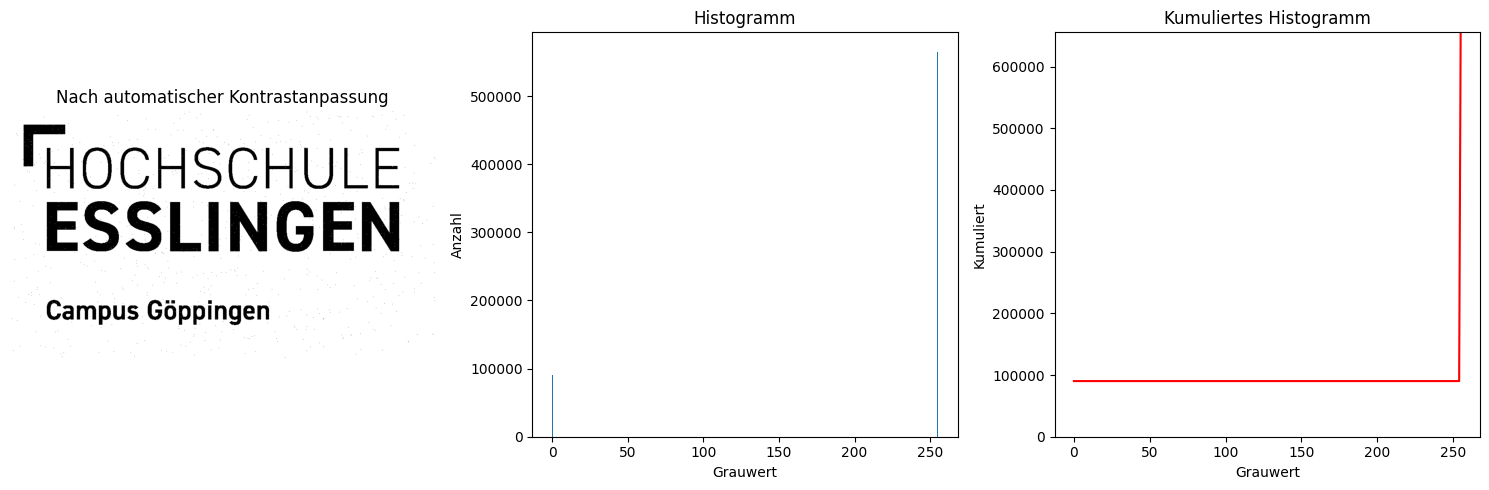

In [9]:
img_landscape_autoCSat = autoContrastSat(img_landscape, satPixPercentage = 1)
displayImageAndAllHist(img_landscape_autoCSat, 'Nach automatischer Kontrastanpassung')

img_unknown_autoCSat = autoContrastSat(img_unknown, satPixPercentage = 1)
displayImageAndAllHist(img_unknown_autoCSat, 'Nach automatischer Kontrastanpassung')

### Histogrammlinearisierung und Histogrammebgleich

Verwenden Sie nun das Paket skimage um eine Histogrammlinearisierung und eineen Histogrammabgleich mit einem Referenzbild durchzuführen. Verwenden Sie dazu die Funktionen `skimage.exposure.equalize_hist` und `skimage.exposure.match_histograms`. 

### Histogrammlinearisierung

### Aufgabe
Verwenden Sie die Funktion `skimage.exposure.equalize_adapthist` um eine adaptive Histogrammlinearisierung durchzuführen. [Dokumentation von skimage.exposure.equalize_adapthist](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.equalize_adapthist). Beachten Sie das das Ergebnis der Funktion im Bereich [0,1] liegt und ggf auf den 8 bit Wertebereich des Ausgangsbildes skaliert werden muss. Testen Sie die Funktion miit dem Lndschaftsbild

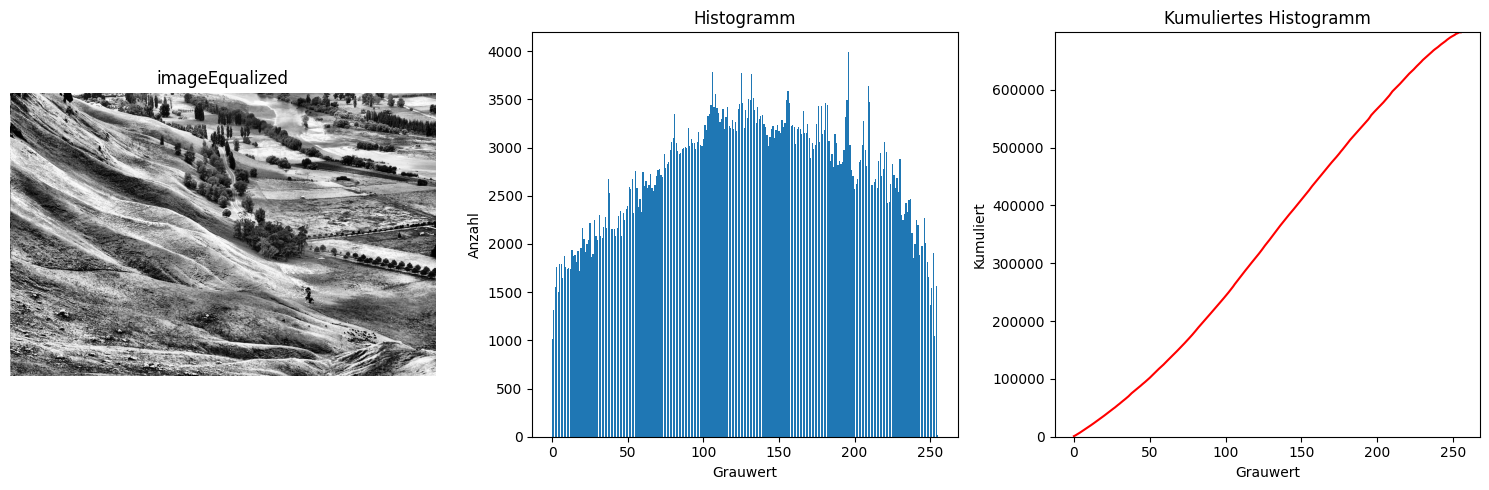

In [ ]:
#####
## ENTER YOU CODE HERE
#####


img_landscape_Eq = skimage.exposure.equalize_adapthist(img_landscape, clip_limit=0.1)
img_landscape_Eq = (img_landscape_Eq*255).astype('uint8')

displayImageAndAllHist(img_landscape_Eq, 'imageEqualized')

### Histogrammabgleich